# Bayesian Forecasting — Barcelona

EDA on the Barcelona price series and the news titles, followed by a **hierarchical Bayesian state-space model** that mirrors the plate diagram:

- Hyperpriors (fixed): $\mu_\beta,\ \sigma_\beta$
- Per-market latent: $\beta_m \sim \mathcal{N}(\mu_\beta, \sigma_\beta)$, $\sigma_m$, $\tau_m$
- Latent state evolution: $\theta_{m,t} = \theta_{m,t-1} + \beta_m\, s_{m,t} + \varepsilon_{m,t},\ \varepsilon_{m,t}\sim\mathcal{N}(0,\sigma_m)$
- Observed price: $p_{m,t} = \mathrm{logit}^{-1}(\theta_{m,t})$ with Beta-likelihood noise
- Terminal observation: $Y_m \mid \theta_{m,T_m} \sim \mathrm{Bernoulli}(\mathrm{logit}^{-1}(\theta_{m,T_m}/\tau_m))$
- Observed input: $s_{m,t}$ — daily news sentiment

Markets $m=1,\dots,M$ are constructed by partitioning the title-overlap window into roughly month-long blocks so the hierarchy has something to pool across.


## 0. Setup

Install PyMC / ArviZ if missing. Skip the cell once it's in your kernel.

In [1]:
# %pip install --quiet pymc arviz
import importlib, subprocess, sys
for pkg in ("pymc", "arviz"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])


In [2]:
# macOS toolchain workaround: PyTensor's C backend fails to link with newer Xcode (`-ld64` missing).
# Falling back to the Python backend lets the model compile + sample, just ~10x slower.
# If you fix your Xcode CLI tools you can drop this line.
import os
os.environ.setdefault("PYTENSOR_FLAGS", "cxx=")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.graphics.tsaplots as tsaplots
from scipy import stats
from scipy.special import expit, logit as scipy_logit

import pymc as pm
import arviz as az

sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(42)
print("PyMC", pm.__version__, "| ArviZ", az.__version__)


/Users/fernandoarroyo/Desktop/Fer&Tayden/Arbitrage/Arb/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC 5.28.4 | ArviZ 0.23.4


## 1. Load and align data

In [3]:
barcelona = pd.read_csv("data/barcelona.csv")
barcelona = barcelona.rename(columns={"timestamp": "Date", "Barcelona": "Prob"})
barcelona["Date"] = pd.to_datetime(barcelona["Date"]).dt.tz_localize(None).dt.normalize()
barcelona = (
    barcelona.set_index("Date").asfreq("D").ffill().reset_index()
)

titles = pd.read_csv("data/barca_titles.csv")
titles["Date"] = pd.to_datetime(titles["Date"]).dt.normalize()
titles["Titles"] = titles["Titles"].fillna("").astype(str)

df = barcelona.merge(titles, on="Date", how="left")
df["HasTitle"] = df["Titles"].notna() & (df["Titles"].str.len() > 0)
df["Titles"] = df["Titles"].fillna("")
df["LogOdds"] = scipy_logit((df["Prob"] / 100).clip(1e-3, 1 - 1e-3))
df.head()


,Date,Prob,Titles,HasTitle,LogOdds
0,2025-08-04,54.0,"All set for final game of Asia tour, Marc Casa...",True,0.160343
1,2025-08-05,54.0,,False,0.160343
2,2025-08-06,54.0,"Barça return home from Asia tour, Marc-André t...",True,0.160343
3,2025-08-07,54.0,"Barça return home from Asia tour, Marc-André t...",True,0.160343
4,2025-08-08,54.0,"Lamine Yamal headlines Ballon d’Or nominees, I...",True,0.160343


In [4]:
print("Date range:", df['Date'].min().date(), "→", df['Date'].max().date())
print("Total days:", len(df))
print("Days with at least one title:", df['HasTitle'].sum())
print("Title-overlap window:",
      df.loc[df['HasTitle'], 'Date'].min().date(),
      "→",
      df.loc[df['HasTitle'], 'Date'].max().date())


Date range: 2025-08-04 → 2026-04-01
Total days: 241
Days with at least one title: 88
Title-overlap window: 2025-08-04 → 2025-10-31


## 2. EDA

We want to know:
1. How does the Barcelona probability evolve?
2. How frequent / clustered are the news titles?
3. Is there a relationship between news flow and price moves?
4. Is the series stationary? What's the dependence structure?

In [5]:
print(df[['Prob', 'LogOdds']].describe().round(3))


          Prob  LogOdds
count  241.000  241.000
mean    54.945    0.215
std     13.325    0.582
min     26.040   -1.044
25%     47.000   -0.120
50%     55.000    0.201
75%     61.700    0.477
max     81.980    1.515


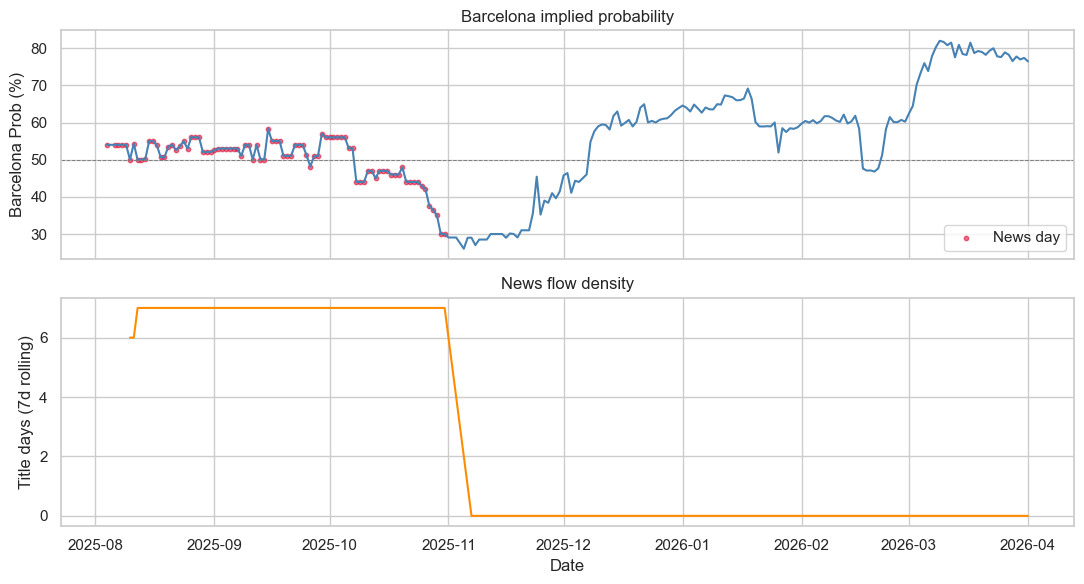

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(df['Date'], df['Prob'], color='steelblue')
axes[0].set_ylabel('Barcelona Prob (%)')
axes[0].set_title('Barcelona implied probability')
axes[0].axhline(50, color='gray', ls='--', lw=0.7)

# Mark days with titles
title_days = df[df['HasTitle']]
axes[0].scatter(title_days['Date'], title_days['Prob'],
                s=10, color='crimson', alpha=0.6, label='News day')
axes[0].legend(loc='lower right')

# Title volume over time
counts = df['HasTitle'].astype(int).rolling(7).sum()
axes[1].plot(df['Date'], counts, color='darkorange')
axes[1].set_ylabel('Title days (7d rolling)')
axes[1].set_xlabel('Date')
axes[1].set_title('News flow density')
plt.tight_layout()
plt.show()


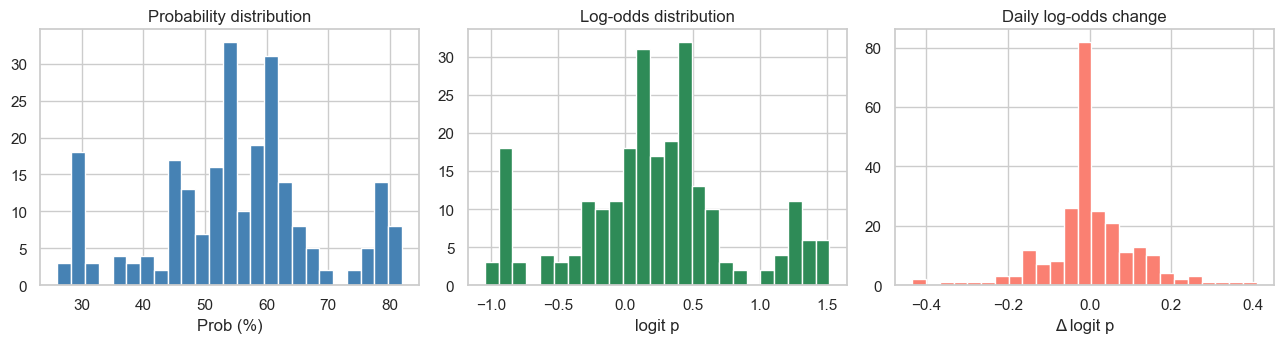

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(df['Prob'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Probability distribution'); axes[0].set_xlabel('Prob (%)')
axes[1].hist(df['LogOdds'], bins=25, color='seagreen', edgecolor='white')
axes[1].set_title('Log-odds distribution'); axes[1].set_xlabel('logit p')
axes[2].hist(df['LogOdds'].diff().dropna(), bins=25, color='salmon', edgecolor='white')
axes[2].set_title('Daily log-odds change'); axes[2].set_xlabel('Δ logit p')
plt.tight_layout(); plt.show()


### 2.1 Sentiment score

We build a simple, transparent **lexicon-based polarity** score in $[-1,1]$ per day. Swap in BART/VADER if you prefer; the rest of the pipeline only needs a numeric daily signal $s_t$.

In [8]:
POS = {
    "win","wins","won","beat","triumph","champion","champions","victory","scored",
    "goal","goals","milestone","record","return","reinstated","extension","renew","renewed",
    "agreement","signed","signs","clinch","clinched","comeback","leader","leading","top",
    "boost","star","brilliant","clinical","historic","masterclass","headlines",
}
NEG = {
    "lose","loses","lost","defeat","defeated","crisis","chaos","drama","injury","injured",
    "out","ban","banned","fail","fails","failed","decline","drop","dropped","setback","slump",
    "scandal","controversy","uncertain","unrest","exit","leave","leaving","departure","fine",
    "fined","probe","investigation","war","tension","problem","problems","concerns","concern",
    "doubt","doubts","blow","tough","trouble","struggle","struggles","red card","sent off",
}
import re
TOKEN_RE = re.compile(r"[A-Za-zÀ-ÿ']+")

def polarity(text: str) -> float:
    if not text:
        return 0.0
    toks = [t.lower() for t in TOKEN_RE.findall(text)]
    if not toks:
        return 0.0
    pos = sum(t in POS for t in toks)
    neg = sum(t in NEG for t in toks)
    if pos == neg == 0:
        return 0.0
    return (pos - neg) / (pos + neg)

df['Sentiment'] = df['Titles'].apply(polarity)
df['TitleLen'] = df['Titles'].str.len()
df[['Date','Titles','Sentiment','TitleLen']].head(8)


,Date,Titles,Sentiment,TitleLen
0,2025-08-04,"All set for final game of Asia tour, Marc Casa...",-1.0,73
1,2025-08-05,,0.0,0
2,2025-08-06,"Barça return home from Asia tour, Marc-André t...",0.0,73
3,2025-08-07,"Barça return home from Asia tour, Marc-André t...",0.0,73
4,2025-08-08,"Lamine Yamal headlines Ballon d’Or nominees, I...",1.0,85
5,2025-08-09,"Robert Lewandowski hamstring injury confirmed,...",0.0,90
6,2025-08-10,"All set for Joan Gamper Trophy, Iñigo Martínez...",-1.0,66
7,2025-08-11,"Barça win Joan Gamper Trophy, Fermín López con...",1.0,64


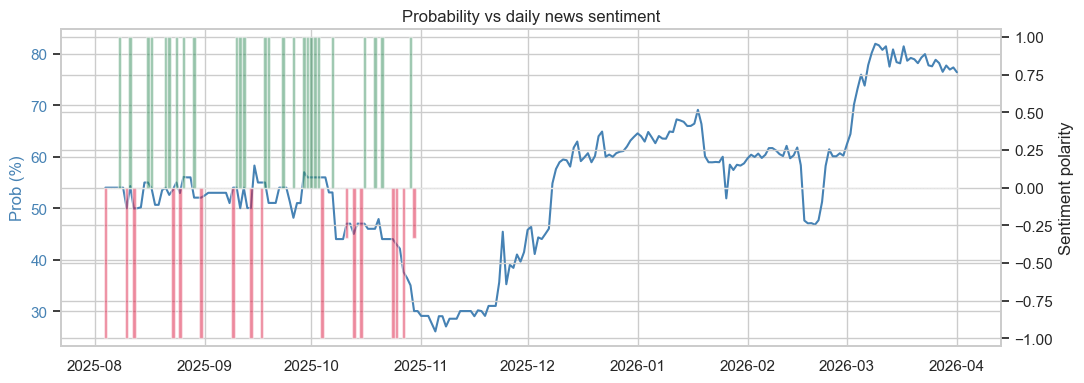

In [9]:
# Sentiment over time, vs probability
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(df['Date'], df['Prob'], color='steelblue', label='Prob (%)')
ax1.set_ylabel('Prob (%)', color='steelblue'); ax1.tick_params(axis='y', labelcolor='steelblue')
ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Sentiment'], width=1.0, alpha=0.5,
        color=np.where(df['Sentiment'] >= 0, 'seagreen', 'crimson'),
        label='Daily sentiment')
ax2.set_ylabel('Sentiment polarity'); ax2.set_ylim(-1.05, 1.05)
ax1.set_title('Probability vs daily news sentiment')
plt.tight_layout(); plt.show()


In [10]:
# Concurrent and lead/lag relationship
df['dLogOdds'] = df['LogOdds'].diff()
mask = df['HasTitle']
print("Pearson(sentiment, dLogOdds, same day):",
      stats.pearsonr(df.loc[mask, 'Sentiment'], df.loc[mask, 'dLogOdds'].fillna(0)))
print("Spearman(sentiment, dLogOdds, same day):",
      stats.spearmanr(df.loc[mask, 'Sentiment'], df.loc[mask, 'dLogOdds'].fillna(0)))


Pearson(sentiment, dLogOdds, same day): PearsonRResult(statistic=np.float64(0.0908859741219492), pvalue=np.float64(0.39970941283830835))
Spearman(sentiment, dLogOdds, same day): SignificanceResult(statistic=np.float64(0.0628753120073598), pvalue=np.float64(0.5605898868958932))


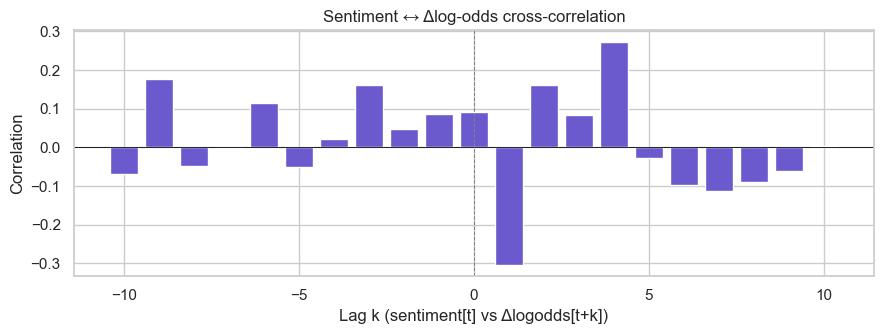

In [11]:
# Cross-correlation: does sentiment lead or lag price moves?
mask = df['HasTitle']
sent = df.loc[mask, 'Sentiment'].to_numpy()
delta = df.loc[mask, 'dLogOdds'].fillna(0).to_numpy()
# Manual symmetric CCF (lag k: sent_t vs delta_{t+k})
maxlag = 10
lags = np.arange(-maxlag, maxlag + 1)
ccf_vals = []
for k in lags:
    if k >= 0:
        a, b = sent[: len(sent) - k], delta[k:]
    else:
        a, b = sent[-k:], delta[: len(delta) + k]
    if a.std() == 0 or b.std() == 0:
        ccf_vals.append(0.0)
    else:
        ccf_vals.append(np.corrcoef(a, b)[0, 1])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(lags, ccf_vals, color='slateblue')
ax.axhline(0, color='black', lw=0.6)
ax.axvline(0, color='gray', ls='--', lw=0.7)
ax.set_xlabel('Lag k (sentiment[t] vs Δlogodds[t+k])')
ax.set_ylabel('Correlation'); ax.set_title('Sentiment ↔ Δlog-odds cross-correlation')
plt.tight_layout(); plt.show()


In [12]:
# Stationarity: ADF on level vs first-difference of log-odds
adf_level = adfuller(df['LogOdds'].dropna(), autolag='AIC')
adf_diff  = adfuller(df['LogOdds'].diff().dropna(), autolag='AIC')
print(f"ADF level     : stat={adf_level[0]:.3f}  p={adf_level[1]:.4f}  lags={adf_level[2]}")
print(f"ADF Δ-logodds : stat={adf_diff[0]:.3f}  p={adf_diff[1]:.4f}  lags={adf_diff[2]}")


ADF level     : stat=-0.784  p=0.8239  lags=1
ADF Δ-logodds : stat=-17.341  p=0.0000  lags=0


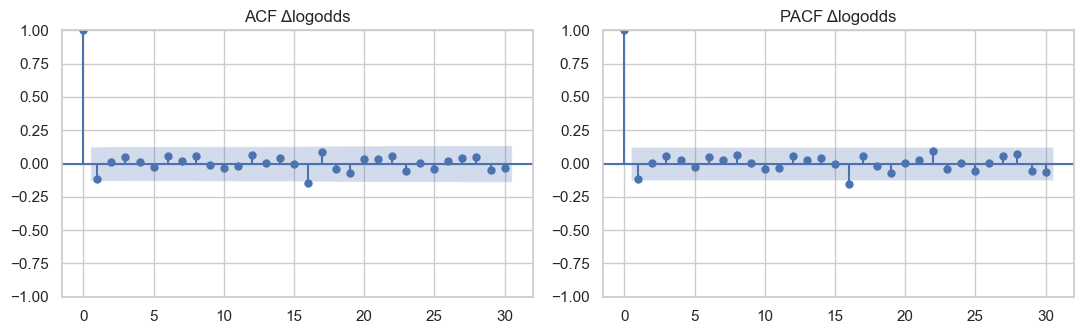

In [13]:
# ACF / PACF of differenced log-odds (returns)
diff = df['LogOdds'].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
tsaplots.plot_acf(diff, lags=30, ax=axes[0]); axes[0].set_title('ACF Δlogodds')
tsaplots.plot_pacf(diff, lags=30, ax=axes[1], method='ywm'); axes[1].set_title('PACF Δlogodds')
plt.tight_layout(); plt.show()


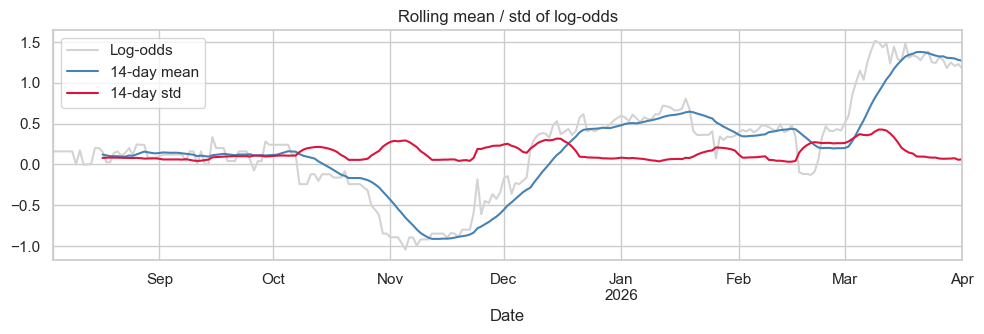

In [14]:
# Rolling mean / std — view of regime shifts
roll = df.set_index('Date')['LogOdds']
fig, ax = plt.subplots(figsize=(10, 3.5))
roll.plot(ax=ax, color='lightgray', label='Log-odds')
roll.rolling(14).mean().plot(ax=ax, color='steelblue', label='14-day mean')
roll.rolling(14).std().plot(ax=ax, color='crimson', label='14-day std')
ax.legend(); ax.set_title('Rolling mean / std of log-odds')
plt.tight_layout(); plt.show()


## 3. Hierarchical Bayesian State-Space Model

Mirroring the plate diagram, with $m$ indexing **markets** (we partition the title-overlap window into roughly equal monthly blocks so the hierarchy has multiple groups to pool across):

$$
\begin{aligned}
\mu_\beta &\sim \mathcal{N}(0, 1) \quad\text{(fixed hyper)}\\
\sigma_\beta &\sim \text{HalfNormal}(0.5)\\
\beta_m \mid \mu_\beta, \sigma_\beta &\sim \mathcal{N}(\mu_\beta, \sigma_\beta) & m=1,\dots,M\\
\sigma_m &\sim \text{HalfNormal}(0.3)\\
\tau_m &\sim \text{HalfNormal}(0.5)\\
\theta_{m,1} &\sim \mathcal{N}(\text{logit}(p_{m,1}^{\text{obs}}), 0.5)\\
\theta_{m,t} \mid \theta_{m,t-1}, \beta_m, s_{m,t} &\sim \mathcal{N}\!\left(\theta_{m,t-1} + \beta_m s_{m,t},\ \sigma_m\right) & t=2,\dots,T_m\\
p_{m,t}^{\text{obs}} &\sim \text{Beta}\!\big(\mu = \mathrm{logit}^{-1}(\theta_{m,t}),\ \kappa\big)\\
Y_m \mid \theta_{m,T_m}, \tau_m &\sim \text{Bernoulli}(\mathrm{logit}^{-1}(\theta_{m,T_m}/\tau_m))
\end{aligned}
$$

$\kappa$ is a global Beta concentration so $p^{\text{obs}}$ has decreasing variance as $\kappa$ grows. $Y_m$ is encoded as $1$ if the market closed above 50% on its terminal day, $0$ otherwise — a stand-in for the eventual binary resolution.


In [15]:
# Restrict to the title-overlap window where s_{m,t} is informative
work = df[df['HasTitle']].copy().reset_index(drop=True)
print(f"Working window: {work['Date'].min().date()} → {work['Date'].max().date()}  ({len(work)} days)")

# Partition into M markets of roughly equal length (~30 days each)
M = 3
work['Market'] = pd.cut(np.arange(len(work)), bins=M, labels=False).astype(int)
print(work.groupby('Market').agg(start=('Date','min'), end=('Date','max'),
                                  T=('Date','size')))


Working window: 2025-08-04 → 2025-10-31  (88 days)
            start        end   T
Market                          
0      2025-08-04 2025-09-03  30
1      2025-09-04 2025-10-02  29
2      2025-10-03 2025-10-31  29


In [16]:
# Build padded arrays: shape (M, T_max), with a mask for valid (m,t)
groups = [g.reset_index(drop=True) for _, g in work.groupby('Market')]
T_lens = [len(g) for g in groups]
T_max  = max(T_lens)

p_obs = np.full((M, T_max), np.nan)
s_obs = np.full((M, T_max), 0.0)
mask  = np.zeros((M, T_max), dtype=bool)
for m, g in enumerate(groups):
    p = (g['Prob'].to_numpy() / 100.0).clip(1e-3, 1 - 1e-3)
    p_obs[m, :len(g)] = p
    s_obs[m, :len(g)] = g['Sentiment'].to_numpy()
    mask[m, :len(g)]  = True

# Terminal outcome Y_m (proxy: closed > 50% on last day of the market window)
Y_obs = np.array([(g['Prob'].iloc[-1] > 50.0) for g in groups]).astype(int)

# Initial state prior mean = logit of first observed price
theta0_mu = np.array([scipy_logit(g['Prob'].iloc[0] / 100.0) for g in groups])

print("p_obs shape:", p_obs.shape, "| Y_obs:", Y_obs, "| theta0_mu:", theta0_mu.round(2))


p_obs shape: (3, 30) | Y_obs: [1 1 0] | theta0_mu: [0.16 0.12 0.24]


In [17]:
coords = {"market": np.arange(M), "time": np.arange(T_max)}

with pm.Model(coords=coords) as hmodel:
    # Hyperpriors
    mu_beta    = pm.Normal("mu_beta", 0.0, 1.0)
    sigma_beta = pm.HalfNormal("sigma_beta", 0.5)

    # Per-market parameters
    beta_m  = pm.Normal("beta_m",  mu=mu_beta, sigma=sigma_beta, dims="market")
    sigma_m = pm.HalfNormal("sigma_m", 0.3, dims="market")
    tau_m   = pm.HalfNormal("tau_m",   0.5, dims="market")

    # Latent states θ_{m,t}: build as an (M, T_max) matrix with a Gaussian random walk
    # whose drift is β_m * s_{m,t}. Innovations ε_{m,t} ~ N(0, σ_m).
    eps = pm.Normal("eps", 0.0, 1.0, dims=("market", "time"))           # standardized
    drift = beta_m[:, None] * s_obs                                      # (M, T_max)
    innov = drift + eps * sigma_m[:, None]                               # (M, T_max)

    # θ_{m,1} ~ N(theta0_mu[m], 0.5); θ_{m,t} = θ_{m,t-1} + drift + ε
    theta0 = pm.Normal("theta0", mu=theta0_mu, sigma=0.5, dims="market")
    theta_path = theta0[:, None] + pm.math.cumsum(innov, axis=1) - innov[:, [0]]
    # zero-out the first-step innovation contribution so theta[:,0] = theta0
    theta = pm.Deterministic("theta", theta_path, dims=("market", "time"))

    # Observation: p_{m,t} ~ Beta with mean = sigmoid(theta), concentration κ
    kappa = pm.HalfNormal("kappa", 50.0)
    p_mu  = pm.math.sigmoid(theta)
    a = p_mu * kappa
    b = (1 - p_mu) * kappa

    pm.Beta(
        "p_obs",
        alpha=a[mask], beta=b[mask],
        observed=p_obs[mask],
    )

    # Terminal outcome Y_m
    last_idx = np.array([t - 1 for t in T_lens])
    theta_T = theta[np.arange(M), last_idx]
    pm.Bernoulli("Y_obs",
                 p=pm.math.sigmoid(theta_T / tau_m),
                 observed=Y_obs)

# Optional: render the plate diagram if `python-graphviz` (and the system binary) is installed.
# pip install graphviz; brew install graphviz   — otherwise we just print the model summary.
try:
    from IPython.display import display
    display(pm.model_to_graphviz(hmodel))
except (ImportError, ModuleNotFoundError):
    print("graphviz not installed — skipping plate diagram render.")
print(hmodel)


graphviz not installed — skipping plate diagram render.


In [18]:
# Sampling. With the Python backend this takes ~5–10 min for these sizes;
# bump draws/tune up if your C backend is healthy.
with hmodel:
    idata = pm.sample(
        draws=500, tune=500, chains=2, cores=2,
        target_accept=0.95, random_seed=42,
        progressbar=True,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_beta, sigma_beta, beta_m, sigma_m, tau_m, eps, theta0, kappa]


/Users/fernandoarroyo/Desktop/Fer&Tayden/Arbitrage/Arb/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 817 seconds.
There were 20 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## 4. Diagnostics

In [19]:
summary = az.summary(idata, var_names=["mu_beta","sigma_beta","beta_m","sigma_m","tau_m","kappa"], round_to=3)
summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_beta,0.010,0.055,-0.090,0.115,0.004,0.007,349.207,224.289,1.013
sigma_beta,0.061,0.092,0.002,0.194,0.006,0.012,197.928,364.693,1.010
beta_m[0],0.012,0.020,-0.025,0.048,0.001,0.001,357.185,261.161,1.010
beta_m[1],0.009,0.016,-0.019,0.042,0.001,0.001,542.952,523.809,1.003
beta_m[2],0.007,0.035,-0.057,0.075,0.002,0.002,599.907,413.559,1.001
sigma_m[0],0.017,0.015,0.000,0.044,0.001,0.001,491.042,664.213,1.004
sigma_m[1],0.024,0.019,0.000,0.058,0.001,0.001,273.204,625.858,1.000
sigma_m[2],0.098,0.023,0.056,0.140,0.001,0.001,587.894,668.280,1.000
tau_m[0],0.365,0.310,0.002,0.931,0.008,0.011,1044.133,505.664,1.001
tau_m[1],0.349,0.285,0.001,0.882,0.009,0.009,693.312,548.259,1.000


In [20]:
# R-hat / ESS distribution at a glance
r_hat = summary['r_hat'].dropna()
ess   = summary['ess_bulk'].dropna()
print("R-hat   max:", r_hat.max(), "  >1.01:", int((r_hat > 1.01).sum()))
print("ESS bulk min:", int(ess.min()), "  <400:", int((ess < 400).sum()))


R-hat   max: 1.013   >1.01: 1
ESS bulk min: 197   <400: 4


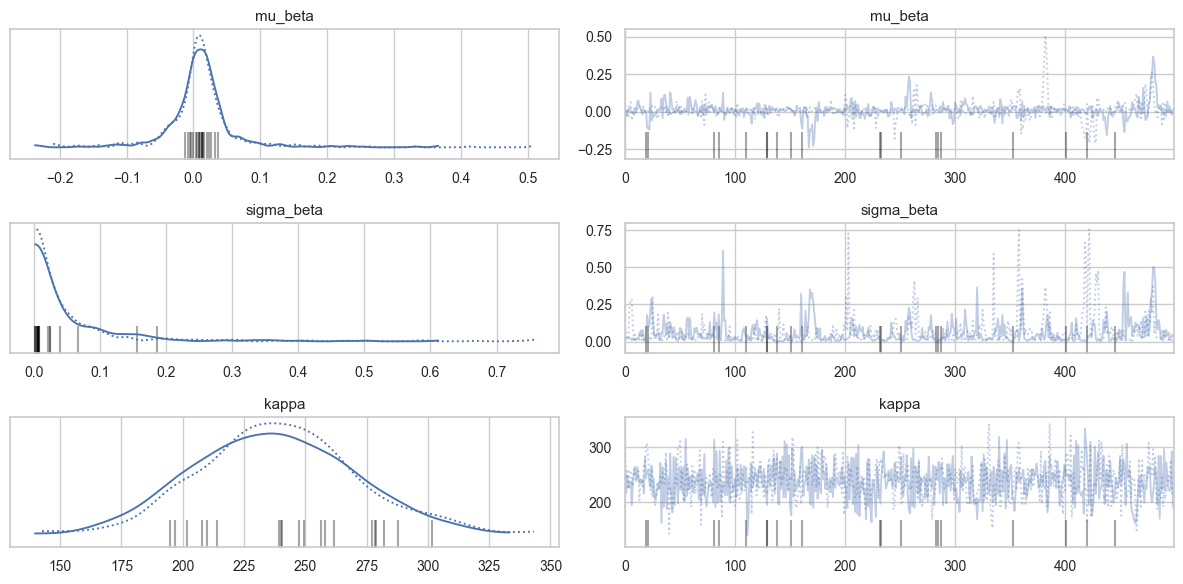

In [21]:
az.plot_trace(idata, var_names=["mu_beta","sigma_beta","kappa"]);
plt.tight_layout(); plt.show()


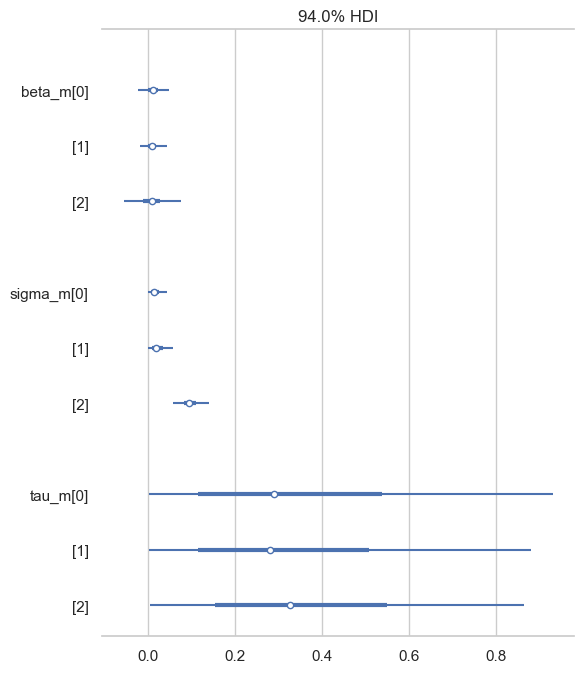

In [22]:
az.plot_forest(idata, var_names=["beta_m","sigma_m","tau_m"], combined=True, hdi_prob=0.94);
plt.tight_layout(); plt.show()


Sampling: [p_obs]


/Users/fernandoarroyo/Desktop/Fer&Tayden/Arbitrage/Arb/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

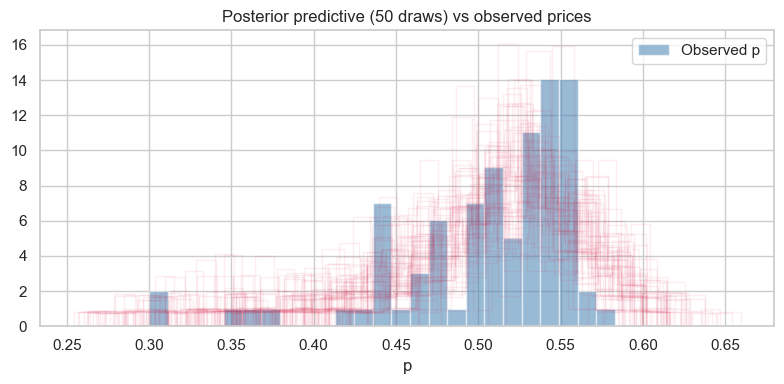

In [23]:
# Posterior predictive check — simulate p_obs and overlay observed
with hmodel:
    ppc = pm.sample_posterior_predictive(idata, var_names=["p_obs"], random_seed=42)

ppc_p = ppc.posterior_predictive["p_obs"].stack(sample=("chain","draw")).values  # (N_obs, S)
obs_flat = p_obs[mask]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(obs_flat, bins=25, density=True, alpha=0.55, color='steelblue', label='Observed p')
sample_idx = RNG.choice(ppc_p.shape[1], size=200, replace=False)
for i in sample_idx[:50]:
    ax.hist(ppc_p[:, i], bins=25, density=True, histtype='step',
            color='crimson', alpha=0.07)
ax.set_title('Posterior predictive (50 draws) vs observed prices')
ax.set_xlabel('p'); ax.legend(); plt.tight_layout(); plt.show()


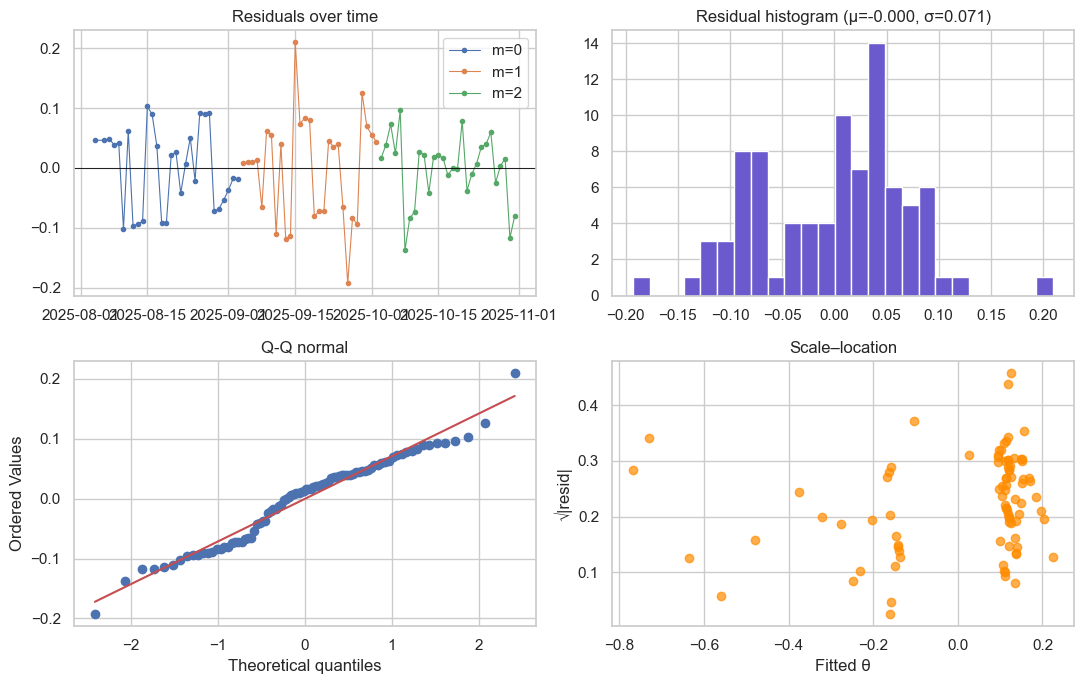

In [24]:
# Reconstruct fitted theta (posterior mean) and residuals on logit scale
theta_post = idata.posterior['theta'].mean(dim=("chain","draw")).values  # (M, T_max)
resid_list, time_list, market_list = [], [], []
for m in range(M):
    T = T_lens[m]
    obs_logit = scipy_logit(p_obs[m, :T])
    fitted_logit = theta_post[m, :T]
    r = obs_logit - fitted_logit
    resid_list.append(r)
    time_list.append(groups[m]['Date'].to_numpy())
    market_list.append(np.full(T, m))
residuals = np.concatenate(resid_list)
res_dates = np.concatenate(time_list)
res_market = np.concatenate(market_list)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
# Time series of residuals, colored by market
for m in range(M):
    sel = res_market == m
    axes[0,0].plot(res_dates[sel], residuals[sel], marker='o', ms=3, lw=0.8, label=f'm={m}')
axes[0,0].axhline(0, color='black', lw=0.6); axes[0,0].legend(); axes[0,0].set_title('Residuals over time')

# Histogram
axes[0,1].hist(residuals, bins=25, color='slateblue', edgecolor='white')
axes[0,1].set_title(f'Residual histogram (μ={residuals.mean():.3f}, σ={residuals.std():.3f})')

# Q-Q
stats.probplot(residuals, dist="norm", plot=axes[1,0]); axes[1,0].set_title('Q-Q normal')

# Scale-location
axes[1,1].scatter(np.concatenate([theta_post[m, :T_lens[m]] for m in range(M)]),
                  np.sqrt(np.abs(residuals)), color='darkorange', alpha=0.7)
axes[1,1].set_xlabel('Fitted θ'); axes[1,1].set_ylabel('√|resid|')
axes[1,1].set_title('Scale–location')
plt.tight_layout(); plt.show()


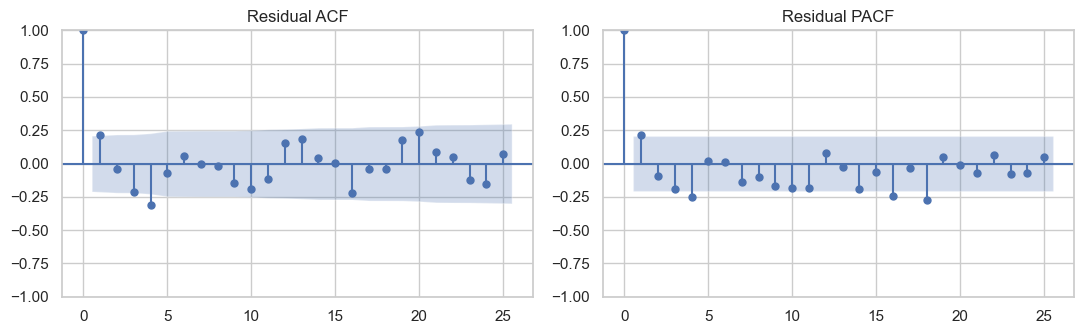

In [25]:
# ACF / PACF of residuals — should look like white noise if the model captured dynamics
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
tsaplots.plot_acf(residuals, lags=25, ax=axes[0]);  axes[0].set_title('Residual ACF')
tsaplots.plot_pacf(residuals, lags=25, ax=axes[1], method='ywm'); axes[1].set_title('Residual PACF')
plt.tight_layout(); plt.show()


In [26]:
# Ljung-Box for residual independence + Shapiro for normality
lb = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)
print("Ljung–Box:")
print(lb.round(4))
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro–Wilk: W={shapiro_stat:.4f}  p={shapiro_p:.4f}")
jb_stat, jb_p = stats.jarque_bera(residuals)
print(f"Jarque–Bera: stat={jb_stat:.3f}  p={jb_p:.4f}")


Ljung–Box:
    lb_stat  lb_pvalue
5   18.2779     0.0026
10  24.4861     0.0064
20  48.1201     0.0004

Shapiro–Wilk: W=0.9713  p=0.0476
Jarque–Bera: stat=0.437  p=0.8037


Divergences per chain: [11  9]


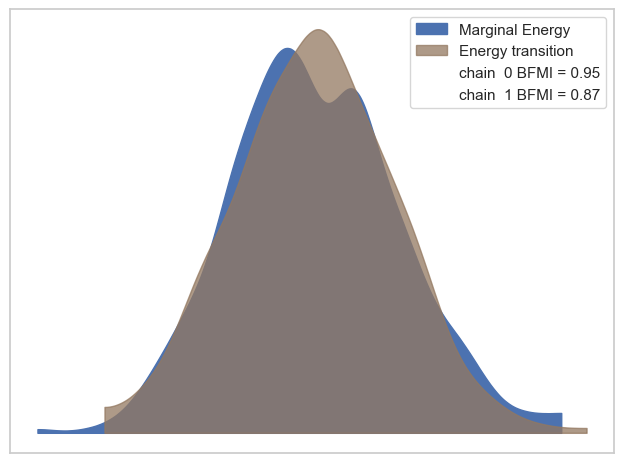

In [27]:
# Energy / divergences and per-chain energy plot
print("Divergences per chain:", idata.sample_stats['diverging'].sum(dim='draw').values)
az.plot_energy(idata); plt.tight_layout(); plt.show()


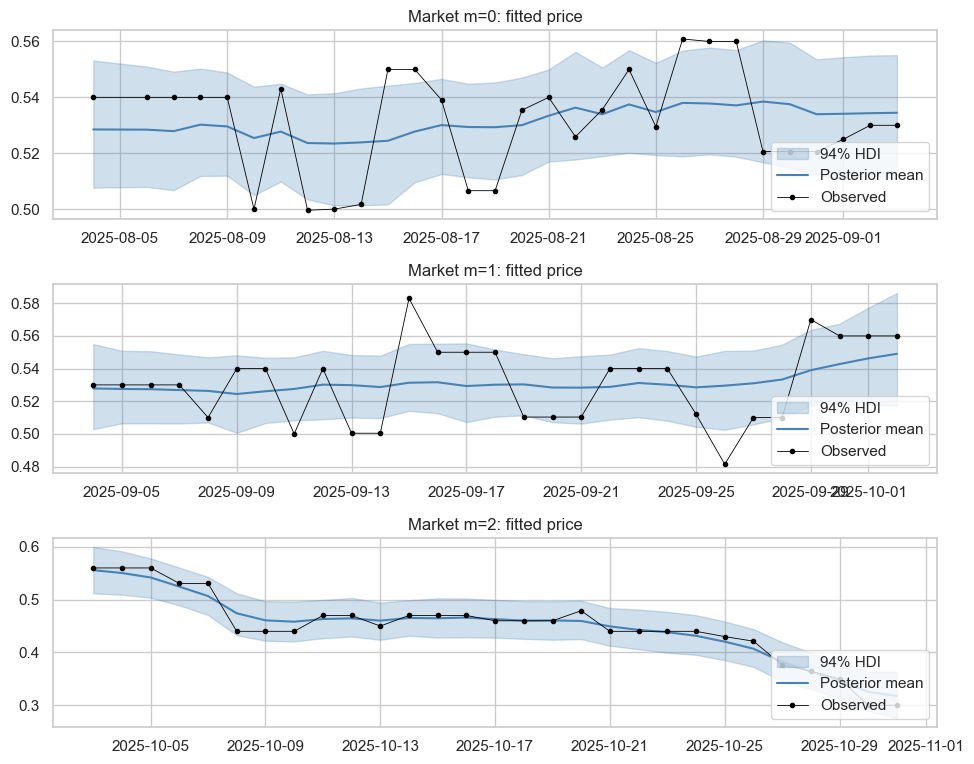

In [28]:
# Posterior predictive: overlay fitted price path per market with 94% HDI
theta_samples = idata.posterior['theta'].stack(sample=("chain","draw")).values  # (M, T_max, S)
fig, axes = plt.subplots(M, 1, figsize=(10, 2.6 * M), sharex=False)
if M == 1:
    axes = [axes]
for m in range(M):
    T = T_lens[m]
    p_samples = expit(theta_samples[m, :T, :])
    lo = np.quantile(p_samples, 0.03, axis=1)
    hi = np.quantile(p_samples, 0.97, axis=1)
    mu = p_samples.mean(axis=1)
    dates = groups[m]['Date'].to_numpy()
    axes[m].fill_between(dates, lo, hi, color='steelblue', alpha=0.25, label='94% HDI')
    axes[m].plot(dates, mu, color='steelblue', label='Posterior mean')
    axes[m].plot(dates, p_obs[m, :T], color='black', marker='o', ms=3, lw=0.6, label='Observed')
    axes[m].set_title(f'Market m={m}: fitted price')
    axes[m].legend(loc='lower right')
plt.tight_layout(); plt.show()


## 5. Notes

- Residual diagnostics above tell us whether the state-space dynamics + Beta observation model captured the time-series structure: if the ACF/PACF of residuals look like white noise and Ljung–Box p-values are large, we're good.
- $\beta_m$ posterior gives the per-window sensitivity to the daily sentiment signal. Pooling toward $\mu_\beta$ regularises markets with sparse news.
- $\tau_m$ controls how confident the terminal outcome $Y_m$ is given $\theta_{m,T_m}$ — large $\tau_m$ means $Y_m$ is almost uninformative.
- Replace the lexicon polarity in §2.1 with BART (matching `forecasting.ipynb`) if you want a stronger sentiment input — only `df['Sentiment']` needs to change.
